In [95]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

# from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
from xgboost import XGBRegressor, XGBRFRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_log_error
import matplotlib.pyplot as plt


TARGET = 'Calories'
USED_COLUMNS = ['']

# load dataetition dataset
comp = pd.read_csv('data/train.csv', index_col='id').astype({'Sex': 'category', 'Age': 'float64'})
# load original dataset
orig = pd.read_csv('data/calories.csv', index_col='User_ID').rename(columns={'Gender': 'Sex'}).astype({'Sex': 'category'})
# concatenate
df = pd.concat([comp, orig]).reset_index(drop=True)

# load test part
test = pd.read_csv('data/test.csv', index_col='id').astype({'Sex': 'category', 'Age': 'float64'})
test[TARGET] = 0

In [83]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36.0,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64.0,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51.0,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20.0,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38.0,166.0,61.0,25.0,102.0,40.6,146.0


In [46]:
# def checkup(estimator_base, X, y, folds=7, scaler_class=None, clip=(-np.inf, np.inf)):
#     metrics = []
#     # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
#     kf = KFold(n_splits=folds, shuffle=True, random_state=19)
#     estimator = estimator_base
#     for f, (train, valid) in enumerate(kf.split(X, y)):
#         if scaler_class:
#             scaler = scaler_class()
#             _yt = scaler.fit_transform(y[train].to_numpy().reshape(-1, 1))[:, 0]
#             _yv = scaler.transform(y[valid].to_numpy().reshape(-1, 1))[:, 0]
#         else:
#             scaler = None
#             _yt, _yv = y[train], y[valid]

#         estimator = deepcopy(estimator_base)
#         estimator.fit(X.loc[train], _yt)

#         pt = estimator.predict(X.loc[train])
#         pv = estimator.predict(X.loc[valid])

#         if scaler:
#             RMSLE_train = root_mean_squared_log_error(y[train], np.clip(scaler.inverse_transform(pt.reshape(-1, 1)), *clip)[:, 0])
#             RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(scaler.inverse_transform(pv.reshape(-1, 1)), *clip)[:, 0])
#         else:
#             RMSLE_train = root_mean_squared_log_error(y[train], np.clip(pt, *clip))
#             RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(pv, *clip))

#         metrics.append((RMSLE_train, RMSLE_valid))
#         print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
#     means = np.mean(metrics, axis=0)
#     print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
#     return estimator

In [47]:
def checkup(estimator_base, X, y, folds=7, scaler=None, clip=(-np.inf, np.inf)):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict(X.loc[train])
        pv = estimator.predict(X.loc[valid])

        if scaler:
            RMSLE_train = root_mean_squared_log_error(
                scaler.inverse_transform(y[train].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pt.reshape(-1, 1)), *clip)[:, 0]
            )
            RMSLE_valid = root_mean_squared_log_error(
                scaler.inverse_transform(y[valid].reshape(-1, 1)),
                np.clip(scaler.inverse_transform(pv.reshape(-1, 1)), *clip)[:, 0]
            )
        else:
            RMSLE_train = root_mean_squared_log_error(y[train], np.clip(pt, *clip))
            RMSLE_valid = root_mean_squared_log_error(y[valid], np.clip(pv, *clip))

        metrics.append((RMSLE_train, RMSLE_valid))
        print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
    return estimator

__Feature engineering__

In [84]:
ORIGIN = df.columns.to_list()

pipe = make_pipeline(
    # Recast categories
    # Calc('Sex.cat.codes', to='Sex'),
    Calc('(Sex == "male").astype(int)', to='Sex'),
    # Body-mass index
    Calc('Weight / (Height / 100) ** 2', to='BMI'),
    # WTF
    Calc('np.log(Heart_Rate * Body_Temp / Duration)', to='activity_index'),
    Calc('Heart_Rate / Body_Temp', to='HeartRateBodyTemp_Ratio'),
    Calc('Body_Temp / Duration', to='BodyTempDuration_Ratio'),
    Calc('Weight / Duration', to='WeightDuration_Ratio'),
    Calc('Heart_Rate / Duration', to='HeartRateDuration_Ratio'),

    # bins
    # Bins('Age', to='ct_Age', bins=25),
    # Bins('Duration', to='ct_Duration', bins=25),
    # Bins('Weight', to='ct_Weight', bins=25),

    # groups
    WithSelected(r'(?!Sex|mean_|ct_)')(Group('Age', 'mean', prefix='mean_Age_', include_target=True)),
    WithSelected(r'(?!Sex|mean_|ct_)')(Group('Duration', 'mean', prefix='mean_Duration_', include_target=True)),
    WithSelected(r'(?!Sex|mean_|ct_)')(Group('Weight', 'mean', prefix='mean_Weight', include_target=True)),
    # ---
    WithSelected(r'(?!mean_|ct_)')(Group(['Sex', 'Age'], 'mean', prefix='mean_SexAge_', include_target=True)),
    WithSelected(r'(?!mean_|ct_)')(Group(['Sex', 'Duration'], 'mean', prefix='mean_SexDuration_', include_target=True)),
    WithSelected(r'(?!Sex|mean_|ct_)')(Group(['Age', 'Duration'], 'mean', prefix='mean_AgeDuration_', include_target=True)),
    WithSelected(r'(?!Sex|mean_|ct_)')(Group(['Weight', 'Duration'], 'mean', prefix='mean_WeightDuration_', include_target=True)),

    # WithSelected(['Age'])(Group('Age', 'mean', prefix='mean_Age_', include_target=True)),
    # WithSelected(['Duration'])(Group('Duration', 'mean', prefix='mean_Duration_', include_target=True)),
    # WithSelected(['Weight'])(Group('Weight', 'mean', prefix='mean_Weight', include_target=True)),
    # # ---
    # WithSelected(['Sex', 'Age'])(Group(['Sex', 'Age'], 'mean', prefix='mean_SexAge_', include_target=True)),
    # WithSelected(['Sex', 'Duration'])(Group(['Sex', 'Duration'], 'mean', prefix='mean_SexDuration_', include_target=True)),
    # WithSelected(['Age', 'Duration'])(Group(['Age', 'Duration'], 'mean', prefix='mean_AgeDuration_', include_target=True)),
    # WithSelected(['Weight', 'Duration'])(Group(['Weight', 'Duration'], 'mean', prefix='mean_WeightDuration_', include_target=True)),


    # drop columns
    # Select(['Sex', 'Age', 'Height'], mode='drop'),
    # Select(r'mean_|Sex|activity_index', mode='keep'),

    # fill NaN
    Fill('mean'),

    # standardize
    # KeepDataframe(make_pipeline(
    #     pre.StandardScaler(),
    #     pre.PowerTransformer(standardize=False)
    # )),
    WithSelected(r'(?!Sex)')(
        KeepDataframe(make_pipeline(
            # pre.QuantileTransformer(random_state=17),
            pre.PowerTransformer(standardize=True),
            # pre.PowerTransformer(standardize=False),
            # pre.MinMaxScaler(),
            # pre.StandardScaler(),
            # pre.RobustScaler(),
        )),
    ),
)
y_pipe = pre.PowerTransformer()

X: pd.DataFrame = pipe.fit_transform(df.drop(columns=TARGET), df[TARGET])     # type: ignore
y = y_pipe.fit_transform(df[TARGET].to_numpy().reshape(-1, 1))[:, 0]
# y = df[TARGET]
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,activity_index,HeartRateBodyTemp_Ratio,...,mean_WeightDuration_Height,mean_WeightDuration_Heart_Rate,mean_WeightDuration_Body_Temp,mean_WeightDuration_BMI,mean_WeightDuration_activity_index,mean_WeightDuration_HeartRateBodyTemp_Ratio,mean_WeightDuration_BodyTempDuration_Ratio,mean_WeightDuration_WeightDuration_Ratio,mean_WeightDuration_HeartRateDuration_Ratio,mean_WeightDuration_Calories
0,1,-0.219612,1.108992,0.547669,1.211090,0.585749,1.638742,-0.938097,-1.329010,0.415369,...,0.457298,1.264386,1.201845,0.817083,-1.199976,1.279759,-1.180017,-0.877680,-1.176525,1.234066
1,0,1.363915,-0.906548,-1.102767,-0.845137,-1.109845,-0.672938,-1.184519,0.795919,-1.203220,...,-1.134930,-0.907848,-0.845624,-0.992697,0.841175,-0.977993,0.845712,0.531630,0.843164,-0.807568
2,0,0.722080,-1.067658,-0.769093,-0.983984,-1.216566,-0.551621,0.208692,0.947727,-1.360577,...,-0.758153,-1.010364,-0.948092,-0.788383,0.986277,-1.086365,0.997472,0.773512,0.996645,-0.932245
3,1,-1.692237,1.332903,1.056994,1.110331,1.006406,0.938071,0.025935,-1.092492,0.981489,...,1.054444,1.134518,1.112492,1.051382,-1.107809,1.151154,-1.093798,-0.625360,-1.094430,1.140690
4,0,-0.076815,-0.666616,-1.017667,1.110331,0.691028,0.730656,-1.479098,-1.195431,0.654257,...,-1.049284,1.196580,1.128347,-0.911083,-1.090733,1.216170,-1.093456,-1.400783,-1.080029,1.102588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764995,0,-1.692237,1.407174,0.807240,-0.452275,-0.365346,0.350830,-0.850752,0.476137,-0.509884,...,0.775858,-0.485336,-0.492274,0.887641,0.448620,-0.506827,0.421402,0.584738,0.426842,-0.486872
764996,0,-0.958619,-0.746365,-0.688371,-1.127824,-1.109845,-1.180681,-0.330415,1.110060,-1.062990,...,-0.667034,-1.211240,-1.154948,-0.743322,1.123298,-1.291040,1.151570,0.958762,1.145317,-1.082809
764997,0,0.254321,-1.229713,-1.276535,0.145903,-0.577617,-0.140713,-0.947053,-0.319885,-0.675759,...,-1.266660,0.055978,0.151800,-1.290607,-0.165369,0.044892,-0.195977,-0.612512,-0.202662,0.146849
764998,1,1.941359,1.407174,1.472735,-1.779280,-1.216566,-1.781218,1.102254,1.807085,-0.935939,...,1.551017,-1.601869,-1.798344,1.204898,1.795096,-1.438031,1.824368,1.930013,1.825107,-1.796202


In [78]:
E = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.01,
    early_stopping=True,
    # alpha=0.001,
    max_iter=2500,
    random_state=19,
)
# E = LinearRegression(
#     n_jobs=-1,
# )
# E = KNeighborsRegressor(  # very slow!
#     n_neighbors=7,
#     n_jobs=-1,
# )
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, None))

Fold: 0; TRAIN RMSLE=0.07129; | VALID RMSLE=0.07177
Fold: 1; TRAIN RMSLE=0.07125; | VALID RMSLE=0.07172
Fold: 2; TRAIN RMSLE=0.07134; | VALID RMSLE=0.07151
Fold: 3; TRAIN RMSLE=0.07162; | VALID RMSLE=0.07031
Fold: 4; TRAIN RMSLE=0.07131; | VALID RMSLE=0.07154
MEAN: TRAIN RMSLE=0.07136; | VALID RMSLE=0.07137


In [ ]:
E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
    # objective='reg:squaredlogerror',
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    verbosity=0,
    device='cuda'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05699; | VALID RMSLE=0.06133
Fold: 1; TRAIN RMSLE=0.05671; | VALID RMSLE=0.06143
Fold: 2; TRAIN RMSLE=0.05673; | VALID RMSLE=0.06041
Fold: 3; TRAIN RMSLE=0.05687; | VALID RMSLE=0.05996
Fold: 4; TRAIN RMSLE=0.05680; | VALID RMSLE=0.06095
MEAN: TRAIN RMSLE=0.05682; | VALID RMSLE=0.06082


In [ ]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='gpu'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05786; | VALID RMSLE=0.06133
Fold: 1; TRAIN RMSLE=0.05746; | VALID RMSLE=0.06159
Fold: 2; TRAIN RMSLE=0.05765; | VALID RMSLE=0.06077
Fold: 3; TRAIN RMSLE=0.05767; | VALID RMSLE=0.05984
Fold: 4; TRAIN RMSLE=0.05762; | VALID RMSLE=0.06093
MEAN: TRAIN RMSLE=0.05765; | VALID RMSLE=0.06089


In [ ]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=500,
    learning_rate=0.3,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

Fold: 0; TRAIN RMSLE=0.05880; | VALID RMSLE=0.06118
Fold: 1; TRAIN RMSLE=0.05860; | VALID RMSLE=0.06163
Fold: 2; TRAIN RMSLE=0.05874; | VALID RMSLE=0.06045
Fold: 3; TRAIN RMSLE=0.05896; | VALID RMSLE=0.05974
Fold: 4; TRAIN RMSLE=0.05879; | VALID RMSLE=0.06103
MEAN: TRAIN RMSLE=0.05878; | VALID RMSLE=0.06080


In [ ]:
# E = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=4,
#     min_samples_leaf=17,
#     random_state=19,
#     n_jobs=-1
# )
# E = GradientBoostingRegressor(
#     n_estimators=500,
#     max_depth=4,
#     random_state=19,
# )
# _ = checkup(E, X, y, folds=5, scaler=y_pipe, clip=(1, np.inf))

100%|██████████| 10/10 [05:31<00:00, 33.16s/it]


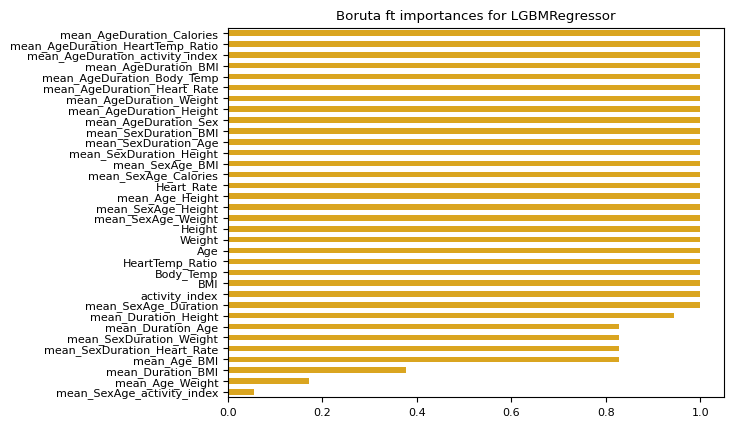

In [27]:
# calculate ft importances
importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)

__Features overview__

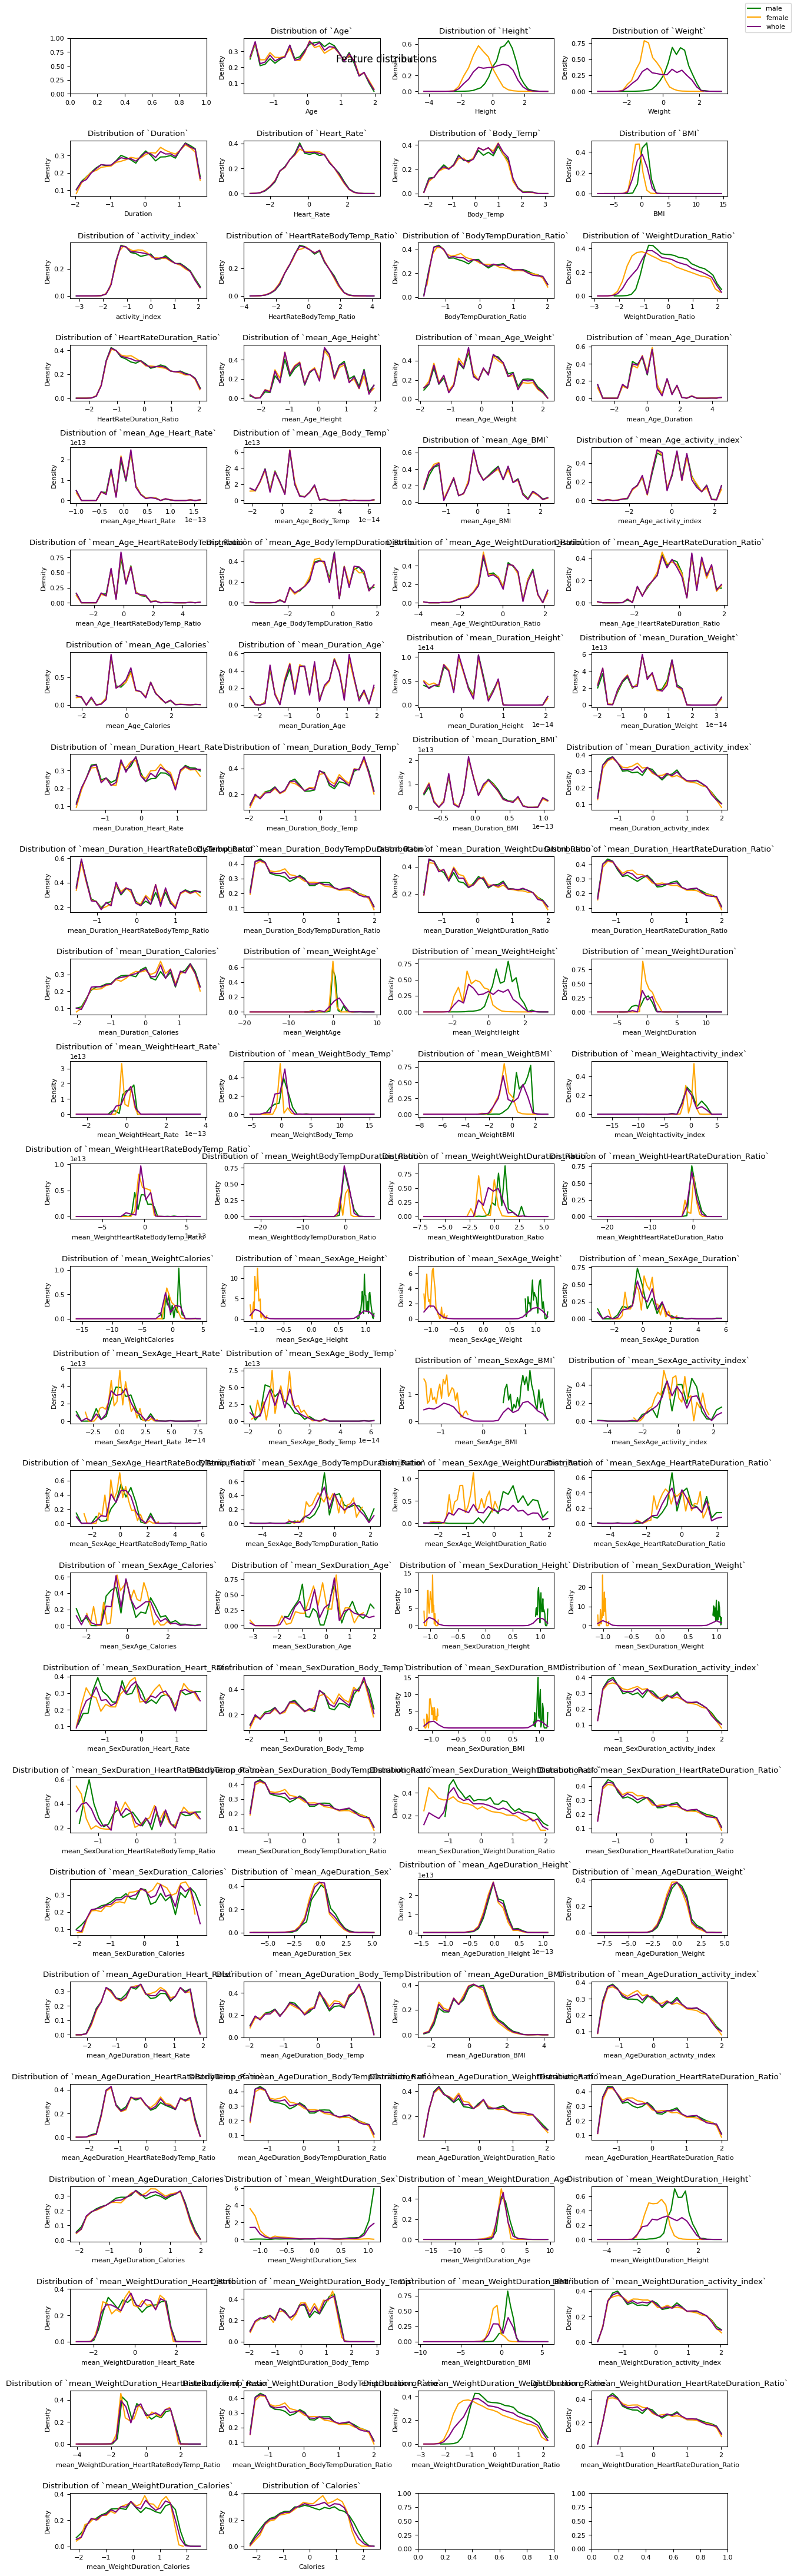

In [72]:
data = X.copy()
# scaler = pre.PowerTransformer()
# data[TARGET] = scaler.fit_transform(y.to_numpy().reshape(-1, 1))
data[TARGET] = y

COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')

MALE = data.Sex == 1
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'Sex':
        # feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')
        ...
    elif feature.startswith('ct_'):
        bins = data[feature].unique().size
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=bins, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=bins, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=bins, color='purple')
    else:
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')

fig.legend(['male', 'female', 'whole'])
plt.show()

__Correlations__

In [24]:
# THRESHOLD = 0.0

# data = X.copy()
# labels = data.columns
# data[TARGET] = y

# CORRELATIONS = ('pearson', 'spearman', 'kendall')
# # CORRELATIONS = ('pearson', )
# # drawing
# fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 4.5), sharex=True)
# fig.set_layout_engine('compressed')
# fig.suptitle('Correlations')
# for n, method in enumerate(CORRELATIONS):
#     ax = axes[n] if len(CORRELATIONS) > 1 else axes
#     ax.set_title(method.capitalize())
#     target_corr = data.corr(method)[[TARGET]].drop(TARGET).sort_values(TARGET, ascending=False)
#     values = target_corr.values.squeeze()
#     filtered = (abs(values) > THRESHOLD)
#     ax.imshow(values[filtered].reshape(1, -1), cmap='Blues')
#     ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
#     ax.set_yticks([0], labels=[TARGET])
# plt.show()

__Final fit__

In [85]:
E = SGDRegressor(
    learning_rate='adaptive',
    eta0=0.01,
    # alpha=0.001,
    max_iter=15000,
    random_state=19,
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
# importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)
sgd = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.07118; | VALID RMSLE=0.07169
Fold: 1; TRAIN RMSLE=0.07147; | VALID RMSLE=0.07125
Fold: 2; TRAIN RMSLE=0.07140; | VALID RMSLE=0.07114
MEAN: TRAIN RMSLE=0.07135; | VALID RMSLE=0.07136


In [86]:
E = XGBRegressor(  # see more https://xgboost.readthedocs.io/en/stable/parameter.html
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    verbosity=0,
    device='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
xgb = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05148; | VALID RMSLE=0.06074
Fold: 1; TRAIN RMSLE=0.05142; | VALID RMSLE=0.06054
Fold: 2; TRAIN RMSLE=0.05155; | VALID RMSLE=0.06015
MEAN: TRAIN RMSLE=0.05148; | VALID RMSLE=0.06048


In [87]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='cuda'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
lgbm = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05264; | VALID RMSLE=0.06083
Fold: 1; TRAIN RMSLE=0.05256; | VALID RMSLE=0.06045
Fold: 2; TRAIN RMSLE=0.05256; | VALID RMSLE=0.06012
MEAN: TRAIN RMSLE=0.05259; | VALID RMSLE=0.06046


In [88]:
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    n_estimators=2500,
    learning_rate=0.2,
    max_depth=4,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    task_type='GPU'
)
_ = checkup(E, X, y, folds=3, scaler=y_pipe, clip=(1, np.inf))
catboost = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05561; | VALID RMSLE=0.06036
Fold: 1; TRAIN RMSLE=0.05559; | VALID RMSLE=0.05981
Fold: 2; TRAIN RMSLE=0.05570; | VALID RMSLE=0.05977
MEAN: TRAIN RMSLE=0.05563; | VALID RMSLE=0.05998


__Submission__

In [18]:
# SGD
T = pipe.transform(test.drop(columns=TARGET))
# values = sgd.predict(T)
values = y_pipe.inverse_transform(sgd.predict(T).reshape(-1, 1))[:, 0]

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b754dfb624fa444eb9e2223fca413af2


In [96]:
# XGB
T = pipe.transform(test.drop(columns=TARGET))
# values = xgb.predict(T)
values = y_pipe.inverse_transform(xgb.predict(T).reshape(-1, 1))[:, 0]

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

fa130f8a940d4296936b46319d3c556a


In [97]:
# LGBM
T = pipe.transform(test.drop(columns=TARGET))
# values = lgbm.predict(T)
values = y_pipe.inverse_transform(lgbm.predict(T).reshape(-1, 1))[:, 0]     # type: ignore

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

19b02d67ecb7484eb74a1503cdf3b9b0


In [98]:
# CatBoost
T = pipe.transform(test.drop(columns=TARGET))
# values = catboost.predict(T)
values = y_pipe.inverse_transform(catboost.predict(T).reshape(-1, 1))[:, 0]

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

819bbed40e624727b548091aa673367c


In [ ]:
#